# <font color="#418FDE" size="6.5" uppercase>**Learning Problems & Evaluation**</font>

>Last update: 20260324.
    
By the end of this Lecture, you will be able to:
- Differentiate among supervised, unsupervised, and semi-supervised learning problems. 
- Select evaluation metrics that align with the safety, cost, or reliability goals. 
- Recognize common data pitfalls such in ME ML projects. 


## **1. Learning Problem Types**

### **1.1. Supervised Learning Basics**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_B/image_01_01.jpg?v=1774395652" width="250">



>* Learns from labeled inputs and known answers.
>* Handles classification and regression for predictions.

>* Predicts engineering outcomes from measured conditions.
>* Uses labeled past cases for decisions.

>* Define clear targets with consistent labels.
>* Use timely, relevant features for decisions.



Supervised learning uses inputs and known labels.
Classification example: road repair yes or no.
Regression example: mechanical component strength prediction.
Classification accuracy: 1.0
Regression MAE: 1.52
Classification inputs: ['system_throughput', 'rain']
Regression inputs: ['cement', 'water']


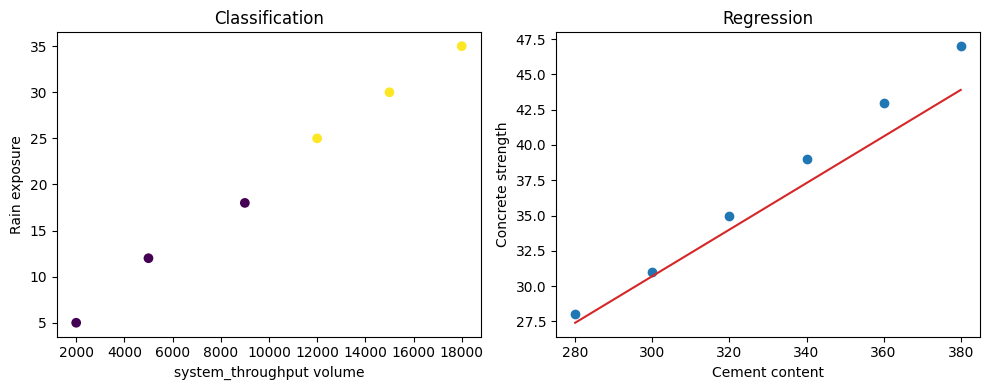

In [21]:
#@title Python Code - Supervised Learning Basics

# Supervised learning uses labeled engineering examples.
# Classification predicts classes from measured features.
# Regression predicts numbers from measured features.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set a seed for repeatable results.
np.random.seed(7)

# Build a small classification dataset.
system_throughput = np.array([2000, 5000, 9000, 12000, 15000, 18000])
rain = np.array([5, 12, 18, 25, 30, 35])

# Labels show known maintenance outcomes.
needs_repair = np.array([0, 0, 0, 1, 1, 1])
class_df = pd.DataFrame({

    "system_throughput": system_throughput, "rain": rain, "repair_label": needs_repair})

# Build a small regression dataset.
cement = np.array([280, 300, 320, 340, 360, 380])
water = np.array([190, 185, 180, 175, 170, 165])

# Targets show known mechanical component strengths.
strength = np.array([28, 31, 35, 39, 43, 47])
reg_df = pd.DataFrame({

    "cement": cement, "water": water, "strength": strength})

# Make a simple classification rule.
score = class_df["system_throughput"] / 1000 + class_df["rain"] / 10
predicted_class = (score >= 14).astype(int)

# Make a simple regression formula.
predicted_strength = (
    0.12 * reg_df["cement"] - 0.18 * reg_df["water"] + 28)

# Measure simple supervised learning accuracy.
class_accuracy = (predicted_class == class_df["repair_label"]).mean()
reg_mae = np.abs(predicted_strength - reg_df["strength"]).mean()

# Print the key learning ideas.
print("Supervised learning uses inputs and known labels.")
print("Classification example: road repair yes or no.")

print("Regression example: mechanical component strength prediction.")
print("Classification accuracy:", round(class_accuracy, 2))
print("Regression MAE:", round(reg_mae, 2))

print("Classification inputs:", ["system_throughput", "rain"])
print("Regression inputs:", ["cement", "water"])

# Create one figure with two panels.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(class_df["system_throughput"], class_df["rain"], c=needs_repair)

axes[0].set_title("Classification")
axes[0].set_xlabel("system_throughput volume")

# Finish the first panel labels.
axes[0].set_ylabel("Rain exposure")
axes[1].scatter(reg_df["cement"], reg_df["strength"], color="tab:blue")

axes[1].plot(reg_df["cement"], predicted_strength, color="tab:red")

# Finish the second panel labels.
axes[1].set_title("Regression")
axes[1].set_xlabel("Cement content")

axes[1].set_ylabel("Concrete strength")

# Show the final teaching plot.
plt.tight_layout()
plt.show()


### **1.2. Unsupervised Learning Methods**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_B/image_01_02.jpg?v=1774395683" width="250">



>* Finds patterns in unlabeled engineering data
>* Reveals groups, relationships, and unusual behavior

>* Clustering groups similar mechanical engineering patterns.
>* Reduction and anomalies reveal key signals.

>* Interpret patterns carefully using engineering judgment.
>* Useful for exploration, labeling, and decisions.



Clustering found groups: 20 20
Cluster centers: [[1202.3   43.7]
 [3214.5   69.4]]
Reduction made one summary feature.
First three reduced values: [ -805.93 -1004.79 -1103.57]
Generated settlement samples: [10.08 10.63 10.62 12.73 12.14]


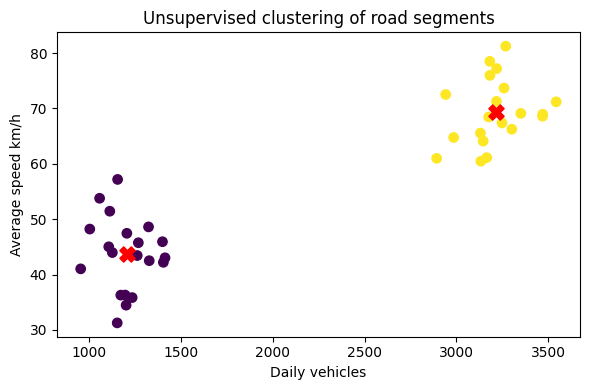

In [22]:
#@title Python Code - Unsupervised Learning Methods

# Unsupervised methods find patterns without labels.
# This example uses simple mechanical data.
# We show clustering, reduction, and generation.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set a seed for repeatability.
np.random.seed(7)

# Create simple system_throughput sensor features.
line_a = np.random.normal(loc=[1200, 45], scale=[120, 6], size=(20, 2))
line_b = np.random.normal(loc=[3200, 70], scale=[180, 5], size=(20, 2))

# Combine two unlabeled road groups.
system_throughput = np.vstack((line_a, line_b))
system_throughput_df = pd.DataFrame(system_throughput, columns=["daily_vehicles", "speed_kmh"])

# Run a tiny k means routine (what is k-means? https://www.youtube.com/watch?v=R2e3Ls9H_fc).
centers = system_throughput[[5, 30]].copy()
for step in range(6):

    d0 = np.sum((system_throughput - centers[0]) ** 2, axis=1)
    d1 = np.sum((system_throughput - centers[1]) ** 2, axis=1)
    labels = (d1 < d0).astype(int)

    centers[0] = system_throughput[labels == 0].mean(axis=0)
    centers[1] = system_throughput[labels == 1].mean(axis=0)

# Build structural sensor style data.
sensor_data = np.column_stack((
    system_throughput_df["daily_vehicles"].values,

    system_throughput_df["speed_kmh"].values,
    0.03 * system_throughput_df["daily_vehicles"].values + np.random.normal(0, 8, 40),
    0.50 * system_throughput_df["speed_kmh"].values + np.random.normal(0, 2, 40)))

# Center data before reduction.
sensor_centered = sensor_data - sensor_data.mean(axis=0)

# Compute a simple first component.
cov_matrix = np.cov(sensor_centered, rowvar=False)
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

pc1 = eigvecs[:, np.argmax(eigvals)]
projection = sensor_centered @ pc1

# Generate synthetic settlement values.
settlement = np.random.normal(loc=12, scale=2, size=8)
synthetic_settlement = np.random.normal(settlement.mean(), settlement.std(), size=5)

# Print short teaching messages.
print("Clustering found groups:", int((labels == 0).sum()), int((labels == 1).sum()))
print("Cluster centers:", np.round(centers, 1))

print("Reduction made one summary feature.")
print("First three reduced values:", np.round(projection[:3], 2))
print("Generated settlement samples:", np.round(synthetic_settlement, 2))

# Plot unlabeled system_throughput groups.
plt.figure(figsize=(6, 4))
plt.scatter(system_throughput[:, 0], system_throughput[:, 1], c=labels, s=45)

plt.scatter(centers[:, 0], centers[:, 1], c="red", s=120, marker="X")
plt.xlabel("Daily vehicles")
plt.ylabel("Average speed km/h")

plt.title("Unsupervised clustering of road segments")
plt.tight_layout()
plt.show()


### **1.3. Semi Supervised Learning**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_B/image_01_03.jpg?v=1774395709" width="250">



>* Uses few labels and many unlabeled examples.
>* Useful when labeling engineering data is costly.

>* Few labels guide, unlabeled data refines.
>* Useful for component_surfaces, mechanical components, and aerial imagery.

>* Uses scarce labels with practical benefits
>* Needs representative data and domain judgment



Semi-supervised component_surface example
Total road images: 40
Expert-labeled images: 4
Unlabeled images: 36
Estimated accuracy: 1.0
Blue means cracked, orange means smooth


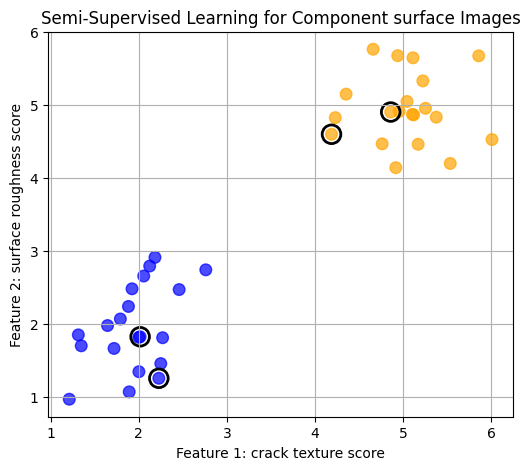

In [23]:
#@title Python Code - Semi Supervised Learning

# Semi supervised learning uses few known labels.
# Mechanical engineering data often include many unlabeled records.
# This example shows simple label spreading ideas.

import numpy as np
import matplotlib.pyplot as plt

# Set a seed for repeatable results.
np.random.seed(7)

# Create two component_surface condition groups.
cracked_x = np.random.normal(2.0, 0.45, 20)
cracked_y = np.random.normal(2.0, 0.45, 20)

smooth_x = np.random.normal(5.0, 0.45, 20)
smooth_y = np.random.normal(5.0, 0.45, 20)

# Combine all road image features.
feature_x = np.concatenate((cracked_x, smooth_x))
feature_y = np.concatenate((cracked_y, smooth_y))

# Store the true classes.
true_labels = np.array(([1] * 20) + ([0] * 20))
points = np.column_stack((feature_x, feature_y))

# Keep only a few expert labels.
known_labels = np.full(40, -1)
known_labels[2] = 1

known_labels[12] = 1
known_labels[25] = 0
known_labels[35] = 0

# Copy labels for simple propagation.
predicted_labels = known_labels.copy()

# Fill unlabeled points using nearest label.
for i in range(len(points)):

    if predicted_labels[i] == -1:
        best_distance = 10**9
        best_label = -1

        for j in range(len(points)):
            if known_labels[j] != -1:
                dx = points[i, 0] - points[j, 0]

                dy = points[i, 1] - points[j, 1]
                distance = (dx * dx + dy * dy) ** 0.5

                if distance < best_distance:
                    best_distance = distance
                    best_label = known_labels[j]

        predicted_labels[i] = best_label

# Measure simple classification accuracy.
accuracy = np.mean(predicted_labels == true_labels)
known_count = np.sum(known_labels != -1)

# Print a short teaching summary.
print("Semi-supervised component_surface example")
print("Total road images:", len(points))

print("Expert-labeled images:", int(known_count))
print("Unlabeled images:", int(len(points) - known_count))
print("Estimated accuracy:", round(float(accuracy), 2))

print("Blue means cracked, orange means smooth")

# Plot all points after label propagation.
colors = ["orange", "blue"]
plot_colors = [colors[int(v)] for v in predicted_labels]

# Show labeled and unlabeled structure.
plt.figure(figsize=(6, 5))
plt.scatter(feature_x, feature_y, c=plot_colors, s=70, alpha=0.7)

# Highlight the expert-labeled points.
plt.scatter(feature_x[known_labels != -1], feature_y[known_labels != -1],
            facecolors="none", edgecolors="black", s=180, linewidths=2)

# Add simple plot labels.
plt.title("Semi-Supervised Learning for Component surface Images")
plt.xlabel("Feature 1: crack texture score")

plt.ylabel("Feature 2: surface roughness score")

# Keep the plot easy to read.
plt.grid(True)
plt.show()


## **2. Evaluation Metrics**

### **2.1. Regression Error Metrics**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_B/image_02_01.jpg?v=1774395740" width="250">



>* Regression metrics assess continuous prediction errors.
>* Original units connect performance to engineering decisions.

>* MAE is simple; RMSE stresses large errors.
>* Pair overall fit with unit-based error.

>* Choose metrics based on error consequences.
>* Match metrics to safety, cost, context.



In [24]:
#@title Python Code - Regression Error Metrics

# Regression metrics support engineering prediction decisions.
# This example uses simple mechanical data.
# We compare typical and large errors.

import math

# Concrete strength example values.
actual_strength = [30, 35, 40, 45, 50]
predicted_strength = [32, 34, 43, 44, 47]

# Check matching list lengths.
if len(actual_strength) != len(predicted_strength):
    raise ValueError("Lists must have equal lengths.")

# Store error values here.
absolute_errors = []
squared_errors = []

# Calculate errors for each case.
for actual, predicted in zip(actual_strength, predicted_strength):
    error = predicted - actual

    absolute_errors.append(abs(error))
    squared_errors.append(error ** 2)

# Compute three common metrics.
mae = sum(absolute_errors) / len(absolute_errors)
mse = sum(squared_errors) / len(squared_errors)

rmse = math.sqrt(mse)

# Show the small engineering dataset.
print("Concrete strength prediction example")
print("Actual values:", actual_strength)

print("Predicted values:", predicted_strength)

# Explain the metric results.
print("MAE:", round(mae, 2), "MPa")
print("MSE:", round(mse, 2), "MPa^2")

print("RMSE:", round(rmse, 2), "MPa")

# Interpret the metrics simply.
print("MAE shows average mistake size.")
print("RMSE penalizes larger mistakes more.")


Concrete strength prediction example
Actual values: [30, 35, 40, 45, 50]
Predicted values: [32, 34, 43, 44, 47]
MAE: 2.0 MPa
MSE: 4.8 MPa^2
RMSE: 2.19 MPa
MAE shows average mistake size.
RMSE penalizes larger mistakes more.


### **2.2. Classification Metrics**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_B/image_02_02.jpg?v=1774395764" width="250">



>* Accuracy alone can hide important classification errors.
>* Choose metrics by false positive, negative costs.

>* Precision and recall capture different error tradeoffs.
>* Choose metrics by engineering context, not F1.

>* Thresholds and imbalance shape classification performance.
>* Choose metrics by safety, cost, reliability.



In [25]:
#@title Python Code - Classification Metrics (watch https://www.youtube.com/watch?v=LbX4X71-TFI&t=226s)

# This script explains basic classification metrics.
# Mechanical engineering examples guide metric interpretation.
# Results show safety and cost tradeoffs.

# Import a small built in module.
import math

# Create mechanical component defect classification labels.
actual = [1, 0, 1, 0, 1, 0, 0, 1, 0, 0]
predicted = [1, 0, 0, 0, 1, 1, 0, 1, 0, 0]

# Check both lists have matching lengths.
if len(actual) != len(predicted):
    raise ValueError("Label lengths must match.")

# Start confusion matrix counts.
tp = 0
fp = 0

fn = 0
tn = 0

# Count each prediction outcome.
for a, p in zip(actual, predicted):
    if a == 1 and p == 1:

        tp = tp + 1
    elif a == 0 and p == 1:
        fp = fp + 1

    elif a == 1 and p == 0:
        fn = fn + 1
    else:

        tn = tn + 1

# Compute common classification metrics (watch https://www.youtube.com/watch?v=jJ7ff7Gcq34).
total = tp + tn + fp + fn
accuracy = (tp + tn) / total

precision = tp / (tp + fp)
recall = tp / (tp + fn)

# Compute the balanced F1 score (watch https://www.youtube.com/watch?v=8d3JbbSj-I8).
f1_score = 2 * precision * recall / (precision + recall)

# Print a short teaching summary.
print("Mechanical component defect example")
print("TP, FP, FN, TN:", tp, fp, fn, tn)

print("Accuracy:", round(accuracy, 2))
print("Precision:", round(precision, 2))

# Explain the remaining metrics briefly.
print("Recall:", round(recall, 2))
print("F1 score:", round(f1_score, 2))

print("High recall helps catch unsafe defects.")
print("High precision avoids unnecessary inspections.")


Mechanical component defect example
TP, FP, FN, TN: 3 1 1 5
Accuracy: 0.8
Precision: 0.75
Recall: 0.75
F1 score: 0.75
High recall helps catch unsafe defects.
High precision avoids unnecessary inspections.


### **2.3. Metrics for Engineering Goals**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_B/image_02_03.jpg?v=1774395805" width="250">



>* Choose metrics based on safety or cost.
>* Check performance across conditions, not averages.

>* Different errors carry different engineering costs.
>* Choose metrics matching decisions, priorities, and tolerances.

>* Check reliability across changing real-world conditions.
>* Use metrics matching safety and engineering decisions.



Mechanical component inspection example
Accuracy: 0.78
Recall for safety: 0.9
Precision for crew efficiency: 0.67
Cost with missed hazards weighted: 290
Concrete strength example
MAE for average error: 1.2
Share within engineering tolerance: 1.0
Best safety metric here: recall
Best cost metric here: weighted cost
Best quality metric here: tolerance rate


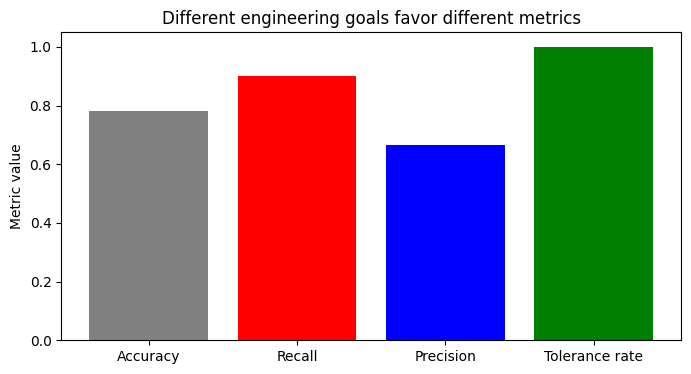

In [26]:
#@title Python Code - Metrics for Engineering Goals

# This script matches metrics to goals.
# Mechanical engineering errors have different costs.
# Simple examples show metric selection clearly.

import numpy as np
import matplotlib.pyplot as plt

# Use a fixed seed here.
np.random.seed(7)

# Define a small confusion matrix (watch https://www.youtube.com/watch?v=bN-yBh4GAeY).
tp, fn, fp, tn = 18, 2, 9, 21

# Compute basic classification metrics.
recall = tp / (tp + fn)
precision = tp / (tp + fp)

accuracy = (tp + tn) / (tp + fn + fp + tn)

# Define a simple cost model.
false_negative_cost = 100
false_positive_cost = 10

# Compute total decision cost.
total_cost = fn * false_negative_cost + fp * false_positive_cost

# Create a small regression example.
true_strength = np.array([30, 32, 35, 40, 45])
pred_strength = np.array([29, 31, 36, 38, 44])

# Compute average absolute error.
mae = np.mean(np.abs(true_strength - pred_strength))

# Check tolerance based acceptance.
tolerance = 2
within_tolerance = np.abs(true_strength - pred_strength) <= tolerance

within_rate = np.mean(within_tolerance)

# Print short teaching messages.
print("Mechanical component inspection example")
print("Accuracy:", round(accuracy, 2))

print("Recall for safety:", round(recall, 2))
print("Precision for crew efficiency:", round(precision, 2))
print("Cost with missed hazards weighted:", total_cost)

print("Concrete strength example")
print("MAE for average error:", round(mae, 2))
print("Share within engineering tolerance:", round(within_rate, 2))

print("Best safety metric here: recall")
print("Best cost metric here: weighted cost")
print("Best quality metric here: tolerance rate")

# Prepare values for one plot.
metric_names = ["Accuracy", "Recall", "Precision", "Tolerance rate"]
metric_values = [accuracy, recall, precision, within_rate]

# Draw one simple comparison plot.
plt.figure(figsize=(8, 4))
plt.bar(metric_names, metric_values, color=["gray", "red", "blue", "green"])

plt.ylim(0, 1.05)
plt.ylabel("Metric value")
plt.title("Different engineering goals favor different metrics")

plt.show()


## **3. Data Pitfalls**

### **3.1. Sampling Bias**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_B/image_03_01.jpg?v=1774395832" width="250">



>* Biased data miss real-world mechanical conditions.
>* Models seem accurate but fail elsewhere.

>* Ask what data is missing, and why.
>* Selective data skews predictions and decisions.

>* Biased samples can hide real safety risks.
>* Engineers must examine data collection carefully.



Full dataset size: 120
Biased sample size: 30
Full average condition: 65.0
Biased average condition: 76.5
Missing group in sample: Rural mechanical components


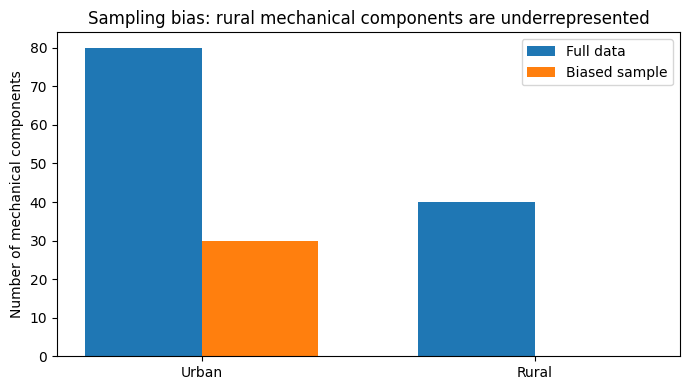

In [27]:
#@title Python Code - Sampling Bias

# This script shows sampling bias simply.
# We compare full and biased mechanical component data.
# One plot reveals missing rural examples.

# Import small libraries for data work.
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Set a seed for repeatability.
np.random.seed(7)

# Create a simple mechanical component dataset.
mechanical_component_type= ["Urban"] * 80 + ["Rural"] * 40

# Create ages for both mechanical component groups.
urban_age = np.random.randint(5, 41, 80)
rural_age = np.random.randint(20, 81, 40)

mechanical_component_age = np.concatenate((urban_age, rural_age))

# Create condition scores by group.
urban_condition = 90 - urban_age * 0.7
rural_condition = 85 - rural_age * 0.8

condition_score = np.concatenate((urban_condition, rural_condition))

# Add small random measurement noise.
noise = np.random.normal(0, 3, 120)
condition_score = condition_score + noise

condition_score = np.clip(condition_score, 20, 100)

# Build the full population table.
data = pd.DataFrame({
    "Location": mechanical_component_type,

    "Age": mechanical_component_age,
    "Condition": condition_score})

# Create a biased sample.
biased_data = data[data["Location"] == "Urban"].copy()
biased_data = biased_data.sample(30, random_state=7)

# Compare average condition values.
full_mean = data["Condition"].mean()
biased_mean = biased_data["Condition"].mean()

# Print a short teaching summary.
print("Full dataset size:", len(data))
print("Biased sample size:", len(biased_data))

print("Full average condition:", round(full_mean, 1))
print("Biased average condition:", round(biased_mean, 1))
print("Missing group in sample: Rural mechanical components")

# Count mechanical components by location.
full_counts = data["Location"].value_counts()
biased_counts = biased_data["Location"].value_counts()

# Prepare values for one plot.
labels = ["Urban", "Rural"]
full_values = [full_counts.get("Urban", 0), full_counts.get("Rural", 0)]

biased_values = [biased_counts.get("Urban", 0), biased_counts.get("Rural", 0)]

# Draw one simple comparison plot.
x = np.arange(len(labels))
width = 0.35

# Plot full and biased counts.
plt.figure(figsize=(7, 4))
plt.bar(x - width / 2, full_values, width, label="Full data")

plt.bar(x + width / 2, biased_values, width, label="Biased sample")

# Add labels and title.
plt.xticks(x, labels)
plt.ylabel("Number of mechanical components")

plt.title("Sampling bias: rural mechanical components are underrepresented")

# Show the legend and plot.
plt.legend()
plt.tight_layout()

plt.show()


### **3.2. Contextual Distribution Shift**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_B/image_03_02.jpg?v=1774395858" width="250">



>* Changing conditions can break model assumptions.
>* Confident predictions may still be wrong.

>* Mechanical systems changes gradually create distribution shift.
>* Models may fail across structures or time.

>* Check whether deployment context matches training data.
>* Validate across sites and monitor drift.



Training region mean temperature: 24.88
New region mean temperature: 4.41
Temperature shift: 20.47
Model roughness = 1.72 + 0.13 * temperature
Test MAE in new context: 3.92
Large error suggests contextual distribution shift.


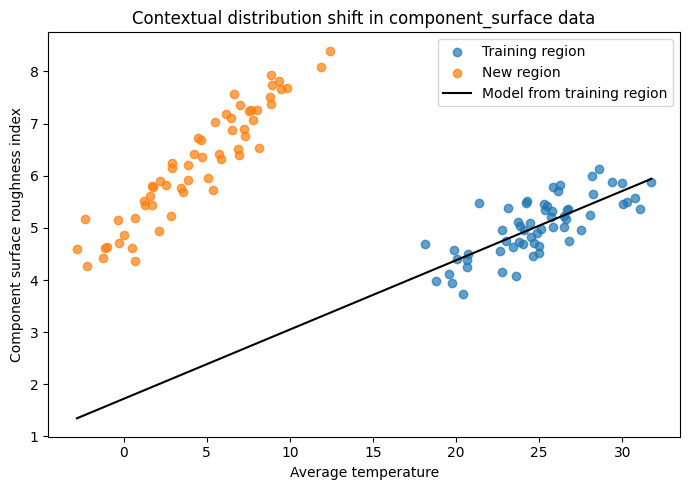

In [28]:
#@title Python Code - Contextual Distribution Shift

# This script shows contextual shift simply.
# We compare two component_surface climate settings.
# Simple math reveals changing model reliability.

# Import small libraries for arrays and plots.
import numpy as np
import matplotlib.pyplot as plt

# Set a seed for repeatable results.
np.random.seed(7)

# Create warm region training temperatures.
train_temp = np.random.normal(25, 3, 60)
# Create roughness from warm region behavior.

train_rough = 2 + 0.12 * train_temp
train_rough = train_rough + np.random.normal(0, 0.4, 60)

# Fit a simple line by hand.
train_mean_x = np.mean(train_temp)
train_mean_y = np.mean(train_rough)

slope = np.sum((train_temp - train_mean_x) * (train_rough - train_mean_y))
slope = slope / np.sum((train_temp - train_mean_x) ** 2)

# Compute the intercept value.
intercept = train_mean_y - slope * train_mean_x

# Create colder region testing temperatures.
test_temp = np.random.normal(5, 4, 60)
# Add freeze thaw pressure vesselage effect.

test_rough = 2 + 0.28 * test_temp + 3

test_rough = test_rough + np.random.normal(0, 0.4, 60)
# Predict using the warm region model.
pred_test = intercept + slope * test_temp

mae = np.mean(np.abs(test_rough - pred_test))

# Compare average temperatures across contexts.
shift_size = np.mean(train_temp) - np.mean(test_temp)
print("Training region mean temperature:", round(np.mean(train_temp), 2))

print("New region mean temperature:", round(np.mean(test_temp), 2))
print("Temperature shift:", round(shift_size, 2))

# Report the simple model equation.
print("Model roughness =", round(intercept, 2), "+", round(slope, 2), "* temperature")
print("Test MAE in new context:", round(mae, 2))

print("Large error suggests contextual distribution shift.")

# Plot both regions and predictions.
plt.figure(figsize=(7, 5))
plt.scatter(train_temp, train_rough, label="Training region", alpha=0.7)

plt.scatter(test_temp, test_rough, label="New region", alpha=0.7)

# Draw the learned warm region line.
x_line = np.array([min(train_temp.min(), test_temp.min()), max(train_temp.max(), test_temp.max())])
y_line = intercept + slope * x_line

plt.plot(x_line, y_line, color="black", label="Model from training region")

# Add labels for the teaching figure.
plt.xlabel("Average temperature")
plt.ylabel("Component surface roughness index")

plt.title("Contextual distribution shift in component_surface data")

# Show the final teaching plot.
plt.legend()
plt.tight_layout()

plt.show()


### **3.3. Safety and Reliability**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_03/Lecture_B/image_03_03.jpg?v=1774395889" width="250">



>* Safety requires performance in critical conditions.
>* Missing high-risk data creates false confidence.

>* Routine data can miss dangerous conditions.
>* Reliable models must handle changing extremes.

>* Error costs differ; evaluate real-world consequences.
>* Validate broadly, quantify uncertainty, keep expert oversight.



Mechanical component defect example
Total cases: 100
Dangerous cases: 10
Accuracy: 0.97
Dangerous cases missed: 3
Recall on dangerous cases: 0.7
Lesson: high accuracy can still be unsafe.


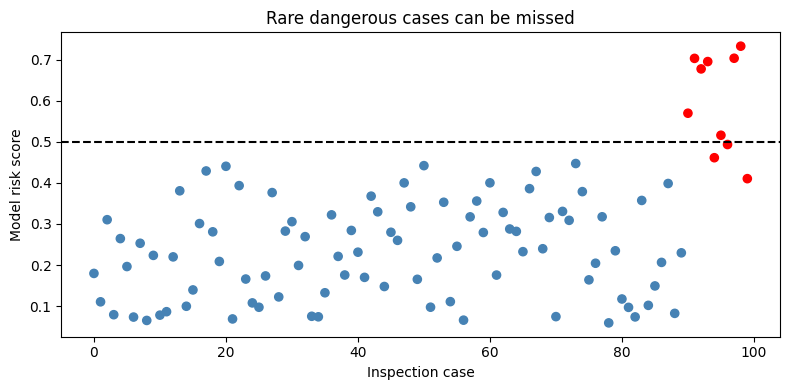

In [29]:
#@title Python Code - Safety and Reliability

# Safety needs careful data choices.
# Rare failures matter most here.
# Simple counts can reveal risk.

import random
import matplotlib.pyplot as plt

# Set a seed for repeatability.
random.seed(7)

# Build mostly normal mechanical component cases.
normal_scores = []
normal_labels = []

for i in range(90):
    normal_scores.append(random.uniform(0.05, 0.45))
    normal_labels.append(0)

# Build a few dangerous cases.
rare_scores = []
rare_labels = []

for i in range(10):
    rare_scores.append(random.uniform(0.35, 0.75))
    rare_labels.append(1)

# Combine all inspection results.
scores = normal_scores + rare_scores
labels = normal_labels + rare_labels

threshold = 0.50

# Count correct and risky decisions.
correct = 0
false_negative = 0

false_positive = 0
for score, label in zip(scores, labels):

    predicted = 1 if score >= threshold else 0
    if predicted == label:
        correct = correct + 1

    if predicted == 0 and label == 1:
        false_negative = false_negative + 1

    if predicted == 1 and label == 0:
        false_positive = false_positive + 1
accuracy = correct / len(labels)

recall = (10 - false_negative) / 10

# Print a short safety summary.
print("Mechanical component defect example")
print("Total cases:", len(labels))

print("Dangerous cases:", sum(labels))
print("Accuracy:", round(accuracy, 2))
print("Dangerous cases missed:", false_negative)

print("Recall on dangerous cases:", round(recall, 2))
print("Lesson: high accuracy can still be unsafe.")

# Prepare colors for the plot.
colors = []
for label in labels:

    colors.append("red" if label == 1 else "steelblue")

# Show normal and dangerous cases.
plt.figure(figsize=(8, 4))
plt.scatter(range(len(scores)), scores, c=colors, s=35)

plt.axhline(threshold, color="black", linestyle="--")

# Add simple labels and title.
plt.title("Rare dangerous cases can be missed")
plt.xlabel("Inspection case")

plt.ylabel("Model risk score")
plt.tight_layout()
plt.show()


# <font color="#418FDE" size="6.5" uppercase>**Learning Problems & Evaluation**</font>


In this lecture, you learned to:
- Differentiate among supervised, unsupervised, and semi-supervised learning problems. 
- Select evaluation metrics that align with the safety, cost, or reliability goals. 
- Recognize common data pitfalls such in ME ML projects. 

In the next Module (Module 4), we will go over 'Introduction to ML, Part II'